In [397]:
import pandas as pd # import biblioteki pozwalającej na wczytanie danych w formie ramki danych, na których możem wykonywac proste operacje 
import re #biblioteka pozwalająca na wyszukiwania wyrażeń regularnych w tekście
import nltk
nltk.download('stopwords') #ściągnięcie słownika z wyrazami nie niosącymi znaczenia tzw.stopwords
nltk.download('wordnet')
from nltk.corpus import stopwords #import biblioteki, która posiada słownik z stopwordsami
import matplotlib.pyplot as plt #blioteka pozwalająca na wizualizacje danych
from matplotlib import cm #import palety kolorów biblioteki matplotlib
import seaborn as sns #blioteka pozwalająca na wizualizacje danych
from wordcloud import WordCloud #biblioteka pozwalającca na tworzenie chmury słów
from nltk.stem import PorterStemmer #biblioteka pozwalajaca na stemantyzację
from nltk.stem.wordnet import WordNetLemmatizer #biblioteka pozwalajaca na lemantyzację
import collections # biblioteka pozwalająca na zliczanie słów, bigramów, trigramów
from nltk import bigrams #biblioteka do tworzenia bigramów
import pickle #biblioteka do tworzenia i otwierania plików w formacie pickle
import stylecloud #biblioteka do tworzenia chmury słów
from googletrans import Translator #biblioteka do tłumaczenia napisanego tekstu na inny język lub detekcji języka

plt.style.use("seaborn-v0_8-whitegrid")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nataliakurczynska/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/nataliakurczynska/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [398]:
data = pd.read_csv("data_clean.csv", index_col = 0)

In [399]:
data

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18
0,comments,cyrus,2017-06-13,2017,dittstm,6gvhln,cysenberg,NaN,I can't believe this sub is devoted to that ho...,1,NaN
1,comments,cyrus,2017-06-13,2017,ditveid,dittstm,cy_guy,NaN,?? what did ido???,1,NaN
2,comments,cyrus,2017-06-13,2017,dityjgt,ditveid,cysenberg,NaN,The sub not your post lol. On the sidebar it s...,1,NaN
3,comments,cyrus,2017-06-13,2017,dityugh,dityjgt,cy_guy,NaN,oh thats fuckin stupid,2,NaN
4,comments,cyrus,2019-10-29,2019,f5o6jgd,doilrx,TBD-101,NaN,Cyrus is the best,10,NaN
...,...,...,...,...,...,...,...,...,...,...,...
108835,posts,queenmileycyrus,2026-05-12,2026,1taul6p,NaN,FlightPrudent4833,Sexy Miley struts around in a sexy dress that ...,NaN,164,0.0
108836,posts,queenmileycyrus,2026-05-12,2026,1tb1w2u,NaN,Sairas_Twuine,queen Miley Cyrus,NaN,26,0.0
108837,posts,queenmileycyrus,2026-05-13,2026,1tbys62,NaN,FlightPrudent4833,"Miley Cyrus looks sexy in the ""Easy Lover"" video",NaN,1,0.0
108838,posts,queenmileycyrus,2026-05-13,2026,1tbz9ap,NaN,joniprv2,Tummy 🔥,NaN,1,0.0


In [400]:
#jezeli w wiersz jest postem to ma tylko title, nie ma body
((data["type"]=="posts") & (data["body"].notna())).any()
#jezeli wiersz jest komentarzem to ma tylko body, nie ma title
((data["type"]=="comment") & (data["title"].notna())).any()

#krocej zapisane ze nie ma takiego wiersza w ktorym i w kolumnie title i body jest cokolwiek
((data["title"].notna()) & (data["body"].notna())).any()

False

In [401]:
data["tresc"] = data[["title","body"]].fillna("").agg(" ".join, axis=1).str.strip() #łączy nam tekst z obu kolumn w jedna kolumne "tresc"
#data_hannah_df = pd.DataFrame(data_hannah, columns=['tresc'])
#data_hannah_df

# ANALIZA DLA HANNAH MONTANA

In [402]:
data_hannah = data[data["subreddit"]=="hannahmontana"]
data_hannah["year"].value_counts()

year
2026    10800
2025     3780
2024     1523
2023      547
2020       42
2022       31
2019       23
2017        9
2021        6
2015        5
2018        5
2013        1
2014        1
2016        1
Name: count, dtype: int64

In [403]:
#OBCINAMY OD ROKU 2024 DO 2026
data_hannah = data[(data["subreddit"]== "hannahmontana") & (data["year"] >= 2024)]
data_hannah

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc
7877,comments,hannahmontana,2024-01-01,2024,kfvdwr9,18fsuvk,ArcticHM,NaN,This is weirder than a three eyed billygoat in...,1,NaN,This is weirder than a three eyed billygoat in...
7878,comments,hannahmontana,2024-01-06,2024,kgl1zfb,18i3a3a,Dramatic_Scholar9385,NaN,"I think so in Hannah Montana: The Movie, Miley...",1,NaN,"I think so in Hannah Montana: The Movie, Miley..."
7879,comments,hannahmontana,2024-01-07,2024,kgp64y6,190iy7o,Ill-Glass4212,NaN,"I said it before, but I won't say 100% that Ja...",-2,NaN,"I said it before, but I won't say 100% that Ja..."
7880,comments,hannahmontana,2024-01-07,2024,kgql84f,190iy7o,raighsunshine,NaN,season 1 & 2 is superior enough said,4,NaN,season 1 & 2 is superior enough said
7881,comments,hannahmontana,2024-01-07,2024,kgr9st7,18admlw,Comfortable-Hall1178,NaN,"There was gonna be a new Lizzie McGuire show, ...",1,NaN,"There was gonna be a new Lizzie McGuire show, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
24451,posts,hannahmontana,2026-05-13,2026,1tc40b8,NaN,New_Persimmon_3507,Does anyone know where I can find the tie-fron...,NaN,1,0.0,Does anyone know where I can find the tie-fron...
24452,posts,hannahmontana,2026-05-13,2026,1tcc8t2,NaN,KaroFlower,Jackson Rod Stewart once said: ⤵️,NaN,1,0.0,Jackson Rod Stewart once said: ⤵️
24453,posts,hannahmontana,2026-05-14,2026,1tcqdad,NaN,BANANA27_,Confused on Oliver and Joannie’s timeline,NaN,1,0.0,Confused on Oliver and Joannie’s timeline
24454,posts,hannahmontana,2026-05-14,2026,1tcrp1j,NaN,HappyCrow11,The test of my love episode is one of my favou...,NaN,1,0.0,The test of my love episode is one of my favou...


In [404]:
data_hannah_df = pd.DataFrame(data_hannah, columns=['tresc'])
data_hannah_df

,tresc
7877,This is weirder than a three eyed billygoat in...
7878,"I think so in Hannah Montana: The Movie, Miley..."
7879,"I said it before, but I won't say 100% that Ja..."
7880,season 1 & 2 is superior enough said
7881,"There was gonna be a new Lizzie McGuire show, ..."
...,...
24451,Does anyone know where I can find the tie-fron...
24452,Jackson Rod Stewart once said: ⤵️
24453,Confused on Oliver and Joannie’s timeline
24454,The test of my love episode is one of my favou...


In [405]:
dictionary = {
    "dont": "don't",
    "didnt": "didn't",
    "wasnt": "wasn't",
    "werent": "weren't",
    "shes": "she's",
    "ive": "I've",
    "cant": "can't",
    "hes": "he's",
    "isnt": "isn't",
    "arent": "aren't"
}

def normalize_text(text):
    new_words = text.split()
    new_words = [dictionary.get(w, w) for w in new_words]
    return " ".join(new_words)

In [406]:
data_hannah_df

,tresc
7877,This is weirder than a three eyed billygoat in...
7878,"I think so in Hannah Montana: The Movie, Miley..."
7879,"I said it before, but I won't say 100% that Ja..."
7880,season 1 & 2 is superior enough said
7881,"There was gonna be a new Lizzie McGuire show, ..."
...,...
24451,Does anyone know where I can find the tie-fron...
24452,Jackson Rod Stewart once said: ⤵️
24453,Confused on Oliver and Joannie’s timeline
24454,The test of my love episode is one of my favou...


In [407]:
#Usuwanie stopwords
def remove_my_stopwords(text):
    stop_words = stopwords.words("english") 
    stop_words.extend(["oah", "haha", "hey", "yeah", "oh", "lol", "omg", "ain't","im", "hannah", "montana", "miley", "would", "could","can't", "also"])
    filtred_words=[]
    for word in text.split():
        if word not in stop_words:
            filtred_words.append(word)
    return filtred_words

In [408]:
data_hannah_string = " ".join(data_hannah_df['tresc'].fillna(""))
data_hannah_string

'This is weirder than a three eyed billygoat in a flat-bed truck in the middle of Manhattan. I think so in Hannah Montana: The Movie, Miley ended up with Travis. I said it before, but I won\'t say 100% that Jake is a cheater. The photo didn\'t even imply anything.\n\nIn fact, there have been a few cases where Miley more so cheated more or less. (Maybe emotional but gah season 1 & 2 is superior enough said There was gonna be a new Lizzie McGuire show, but that got scrapped. I doubt they will do another Hannah Montana series. Miley went to great lengths to remove herself from the series, but if she chose to make another show, I’d watch it, even though I’m 30 and way too old for these shows. Also, I have the same Birthday as Miley, just 1 year younger. So agree with you there. Her long, straight wig was much better than her medium, wavy one Any and all. Season 3, episode 24, Judge Me Tender Jake and Miley never had to be together 100% the only love interest that had genuine intentions and

In [409]:
#oczyszczenie
import emoji

data_hannah_df['tresc'] = data_hannah_df['tresc'].fillna("")
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: str(x).lower())
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub('@([a-zA-Z0-9_]+)', "", x)) #oznaczenia
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(normalize_text)
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_hannah_df['tresc'] = data_hannah_df['tresc'].apply(lambda x: " ".join(x))

In [410]:
data_hannah_str = data_hannah_df['tresc'].fillna("").str.lower().str.split().explode().dropna().tolist()
data_hannah_str

['weirder',
 'three',
 'eyed',
 'billygoat',
 'flatbed',
 'truck',
 'middle',
 'manhattan',
 'think',
 'movie',
 'ended',
 'travis',
 'said',
 'say',
 'jake',
 'cheater',
 'photo',
 'even',
 'imply',
 'anything',
 'fact',
 'cases',
 'cheated',
 'less',
 'maybe',
 'emotional',
 'gah',
 'season',
 'superior',
 'enough',
 'said',
 'gonna',
 'new',
 'lizzie',
 'mcguire',
 'show',
 'got',
 'scrapped',
 'doubt',
 'another',
 'series',
 'went',
 'great',
 'lengths',
 'remove',
 'series',
 'chose',
 'make',
 'another',
 'show',
 'id',
 'watch',
 'even',
 'though',
 'way',
 'old',
 'shows',
 'birthday',
 'year',
 'younger',
 'agree',
 'long',
 'straight',
 'wig',
 'much',
 'better',
 'medium',
 'wavy',
 'one',
 'season',
 'episode',
 'judge',
 'tender',
 'jake',
 'never',
 'together',
 'love',
 'interest',
 'genuine',
 'intentions',
 'loved',
 'yes',
 'actually',
 'worked',
 'tell',
 'loved',
 'movie',
 'like',
 'something',
 'nebraska',
 'right',
 'state',
 'tennessee',
 'name',
 'state',
 'pa

<Axes: xlabel='slowa'>

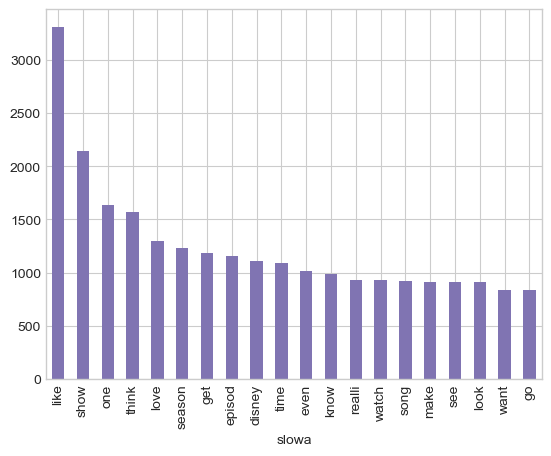

In [411]:
#proces stemantyzacji - sprowadzanie słów do ich rdzeni
#Wywołaj konwerter pozwalający na stemming tekstu za pomocą funkcji PorterStemmer()
ps = PorterStemmer()
#Stwórz pustą listę o nazwie stemmed_words
stemmed_words = []
#Wykonaj pętle po słowach, która będzie każde słowo w bloku tekstu sprowadzać do rdzenia i zapisz je do listy stemmed_words
for word in data_hannah_str:
    stemmed_words.append(ps.stem(word))

lista_slow_stem = pd.DataFrame(stemmed_words)
lista_slow_stem.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_stem.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [412]:
lista_slow_stem.slowa.value_counts().head(40)

slowa
like       3312
show       2139
one        1639
think      1566
love       1297
season     1232
get        1183
episod     1159
disney     1107
time       1086
even       1014
know        991
realli      930
watch       929
song        916
make        915
see         914
look        907
want        840
go          839
got         837
movi        836
special     818
peopl       803
year        769
say         759
feel        734
still       714
thing       675
much        672
rememb      672
fan         632
back        604
never       604
life        588
alway       586
made        581
way         581
actual      570
cast        568
Name: count, dtype: int64

<Axes: xlabel='slowa'>

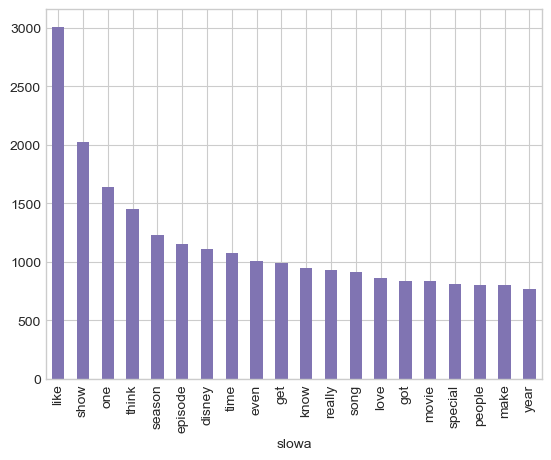

In [413]:
#Lemnadtyzacja - sprowadzenie słów do wersji podstawowej
wnl = WordNetLemmatizer()

lemmed_words = []

for word in data_hannah_str:
    lemmed_words.append(wnl.lemmatize(word))
                        
lista_slow_lem = pd.DataFrame(lemmed_words)
lista_slow_lem.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_lem.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [414]:
lista_slow_lem.slowa.value_counts().head(40)

slowa
like        3008
show        2024
one         1639
think       1452
season      1232
episode     1156
disney      1107
time        1074
even        1011
get          989
know         952
really       930
song         915
love         867
got          837
movie        836
special      809
people       803
make         799
year         769
see          725
still        714
thing        675
much         672
feel         650
life         650
fan          631
remember     630
look         614
never        604
back         593
always       585
way          581
made         581
thats        554
good         551
thought      546
first        541
said         540
say          535
Name: count, dtype: int64

## LISTA TOP SŁÓW 

In [415]:
#data_hannah = data[data["subreddit"]=="hannahmontana"]
#Utwórz ramkę DataFrame z wczytanymi tylko tweetami 
#df = pd.DataFrame(data_hannah, columns=['tresc'])
#df.head()
df = pd.DataFrame(data_hannah_df, columns = ['tresc'])
df

,tresc
7877,weirder three eyed billygoat flatbed truck mid...
7878,think movie ended travis
7879,said say jake cheater photo even imply anythin...
7880,season superior enough said
7881,gonna new lizzie mcguire show got scrapped dou...
...,...
24451,anyone know find tiefront floral shrug
24452,jackson rod stewart said
24453,confused oliver joannies timeline
24454,test love episode one favourites genuinely vib...


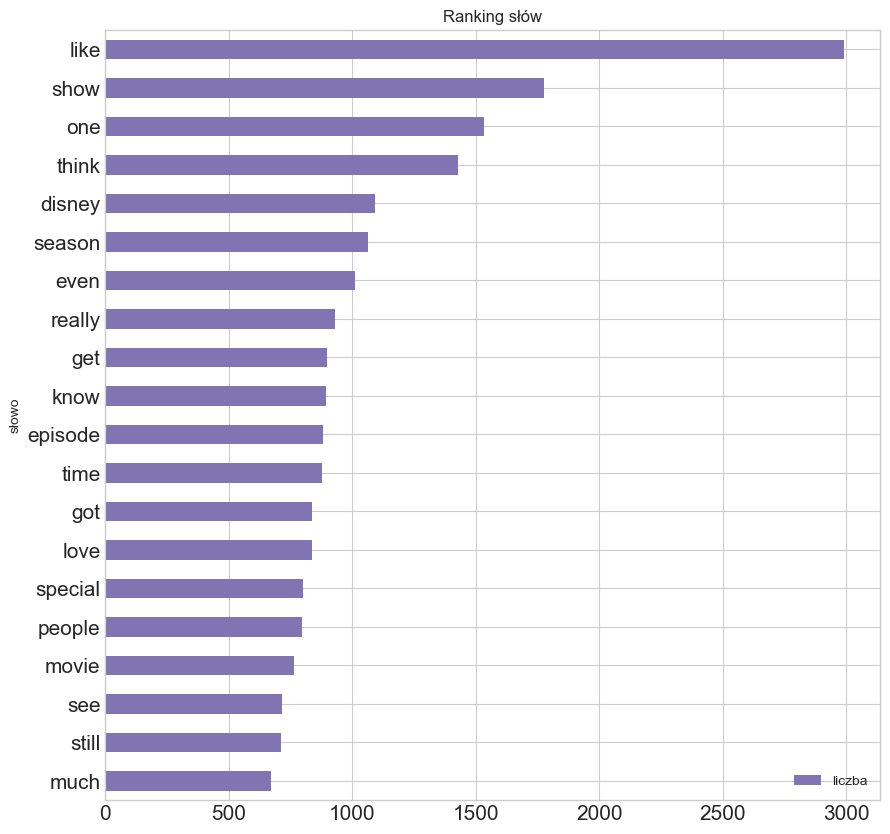

In [416]:
#statystykA częstości występowania słów w postach/komentarzach ze slowek hannahmontana
words = pd.DataFrame(data_hannah_str).value_counts().head(20).rename_axis("słowo").reset_index(name="liczba")
#Zwizualizuj otrzymane wyniki
words.sort_values(by='liczba').plot.barh(x='słowo',y='liczba', figsize=(10,10), fontsize=15, title='Ranking słów', color="#8074B2");

## CHMURA SŁÓW

In [417]:
#words = df['tresc'].str.lower().str.split().explode()
#words = words.dropna()
#words = words.str.strip()
#words = words[words != ""]
word_cloud_words = pd.DataFrame(data_hannah_str).value_counts().head(80).rename_axis("word").reset_index(name="count")
word_cloud_words
wystapienia_hannah = dict(zip(word_cloud_words["word"], word_cloud_words["count"]))
wystapienia_hannah

{'like': 2989,
 'show': 1778,
 'one': 1533,
 'think': 1428,
 'disney': 1091,
 'season': 1062,
 'even': 1011,
 'really': 930,
 'get': 899,
 'know': 892,
 'episode': 881,
 'time': 877,
 'got': 837,
 'love': 836,
 'special': 801,
 'people': 796,
 'movie': 762,
 'see': 715,
 'still': 712,
 'much': 672,
 'remember': 630,
 'never': 604,
 'back': 592,
 'always': 585,
 'made': 581,
 'life': 568,
 'way': 557,
 'thats': 554,
 'good': 551,
 'first': 541,
 'said': 540,
 'song': 530,
 'feel': 525,
 'make': 524,
 'cast': 522,
 'thought': 511,
 'best': 497,
 'something': 497,
 'go': 472,
 'old': 472,
 'years': 470,
 'lot': 454,
 'actually': 435,
 'felt': 429,
 'say': 407,
 'jackson': 404,
 'thing': 403,
 'loved': 399,
 'yes': 396,
 'songs': 385,
 'right': 384,
 'well': 383,
 'real': 379,
 'wanted': 376,
 'sure': 371,
 'going': 367,
 'maybe': 360,
 'girl': 360,
 'cyrus': 359,
 'want': 357,
 'alex': 357,
 'anniversary': 349,
 'look': 346,
 'watch': 343,
 'ray': 340,
 'new': 338,
 'since': 337,
 'fans':

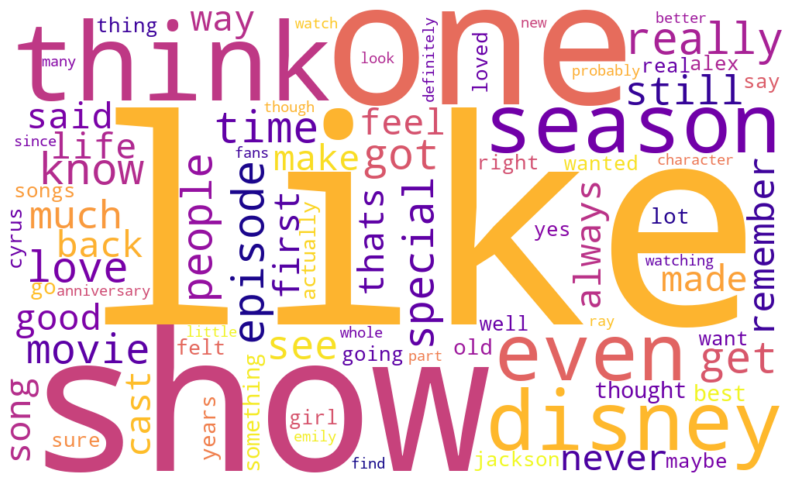

In [418]:
#Utwórz chmurę słów
#Wywołanie obiektu odpowiedzialnego za tworzenie chmury słów WordCloud()
plt.figure(figsize=(10,10))
wc= WordCloud(background_color ='white', max_words = 80, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_hannah)
#Utwórz chmurę słow za pomocą funkcj wc.generate(), a następnie ją wyświetl za pomocą funkcji plt.imshow()
plt.imshow(wc, interpolation='bilinear')
plt.axis('off');

In [419]:
import numpy as np
from PIL import Image
from PIL import ImageFilter

In [420]:
mask = np.array(Image.open("hannahmontana mask.png").convert("L"))
mask = np.where(mask > 100, 255, 0)

In [421]:
colors = ["#dabcff","#deacde","#9e4a9e","#ffc370","#ffc6d0","#800080","#b266b2","#a64ca6","#b266b2"]
color_function = lambda *args, **kwargs: np.random.choice(colors)

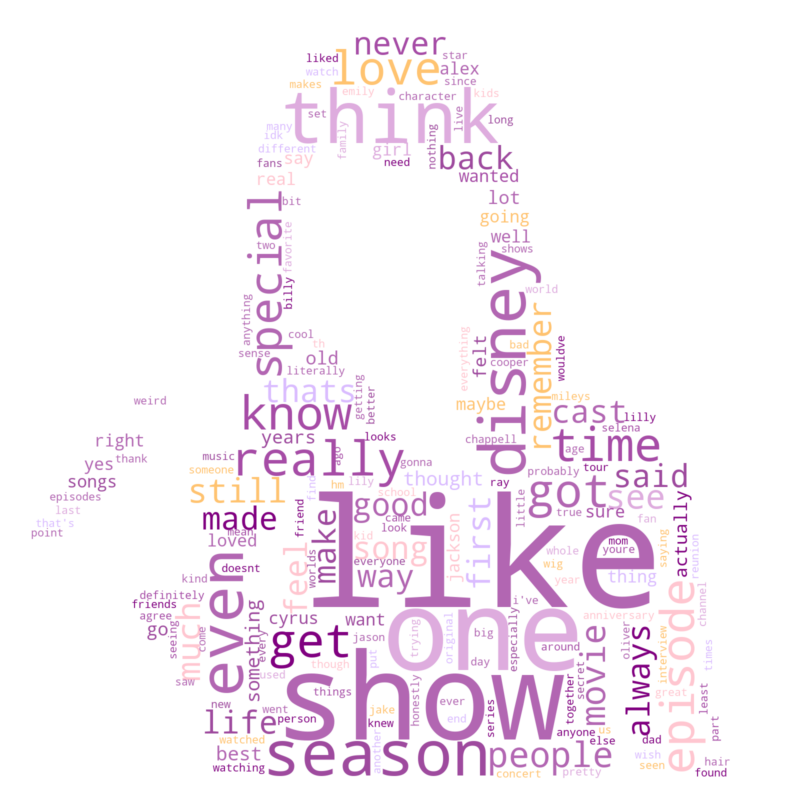

In [422]:
word_cloud_words = pd.DataFrame(data_hannah_str).value_counts().head(200).rename_axis("word").reset_index(name="count")
word_cloud_words
wystapienia_hannah = dict(zip(word_cloud_words["word"], word_cloud_words["count"]))
wystapienia_hannah
plt.figure(figsize=(10,10))
wc= WordCloud(background_color ='white',mask=mask,scale = 1.5,color_func=color_function, max_words = 190, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_hannah)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off');

## ANALIZA WYDŹWIĘKU

In [423]:
from textblob import TextBlob
from nltk.corpus import stopwords, twitter_samples
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
import nltk

In [424]:
from nltk.corpus import stopwords

stop = set(stopwords.words("english"))

safe_stopwords = stop - {
    "not", "no", "nor",
    "don't", "didn't", "wasn't", "won't", "can't",
    "isn't", "aren't", "couldn't", "wouldn't"
}

In [425]:
df = pd.DataFrame(data_hannah, columns=['tresc'])
df

,tresc
7877,This is weirder than a three eyed billygoat in...
7878,"I think so in Hannah Montana: The Movie, Miley..."
7879,"I said it before, but I won't say 100% that Ja..."
7880,season 1 & 2 is superior enough said
7881,"There was gonna be a new Lizzie McGuire show, ..."
...,...
24451,Does anyone know where I can find the tie-fron...
24452,Jackson Rod Stewart once said: ⤵️
24453,Confused on Oliver and Joannie’s timeline
24454,The test of my love episode is one of my favou...


In [426]:
#Usuwanie stopwords
def remove_my_stopwords(text):
    stop_words = safe_stopwords
    stop_words.update({"oah", "haha", "hey", "yeah", "oh", "lol", "omg", "im"})
    filtred_words=[]
    for word in text.split():
        if word not in stop_words:
            filtred_words.append(word)
    return filtred_words

In [427]:
#oczyszczenie
import emoji

df['tresc'] = df['tresc'].fillna("")
df['tresc'] = df['tresc'].apply(lambda x: str(x).lower())
df['tresc'] = df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
df['tresc'] = df['tresc'].apply(lambda x: re.sub('@([a-zA-Z0-9_]+)', "", x)) #oznaczenia
df['tresc'] = df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
df['tresc'] = df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
df['tresc'] = df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
df['tresc'] = df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
df['tresc'] = df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
df['tresc'] = df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
df['tresc'] = df['tresc'].apply(normalize_text)
df['tresc'] = df['tresc'].apply(lambda x: remove_my_stopwords(x))
df['tresc'] = df['tresc'].apply(lambda x: " ".join(x))

In [429]:
hannah_sentiment = df['tresc'].fillna("").str.lower().str.split().explode().dropna()
hannah_sentiment

7877       weirder
7877         three
7877          eyed
7877     billygoat
7877       flatbed
           ...    
24455          one
24455       thinks
24455        miley
24455      stewart
24455         adhd
Name: tresc, Length: 196408, dtype: object

In [430]:
tekst = " ".join(hannah_sentiment)
tekst

"weirder three eyed billygoat flatbed truck middle manhattan think hannah montana movie miley ended travis said won't say jake cheater photo didn't even imply anything fact cases miley cheated less maybe emotional gah season superior enough said gonna new lizzie mcguire show got scrapped doubt another hannah montana series miley went great lengths remove series chose make another show id watch even though way old shows also birthday miley year younger agree long straight wig much better medium wavy one season episode judge tender jake miley never together love interest genuine intentions loved miley yes actually would worked tell loved movie like something nebraska right state tennessee name state party last name tennessee bucky kentucky oliver feel alaska nebraska bucky kentucky bucky kentucky bucky kentucky movie set sesons stopped reading moment saw jesse erasure wdym engaged jake broke jesse don't disrespect like like jesse way better jake need money popularity boost sell album not

In [431]:
#Częstość występowania pozytywnych słów w korpusie
wystapienia = [] #utworzenie pustej listy

with open('pozytywne_slowa.txt') as file: #otworzenie pliku tekstoweo z pozytywnymi słowami
    pozytywne_slowa = file.read().split('\n') #zapisanie pozytywnych słów do zmiennej

    for slowo in pozytywne_slowa: #pętl po słowach pozytywnych
        wystapienia.append(tekst.count(slowo.strip())) #zliczenie słów pozytywnych w tekście za pomocą funkcji count
        
pozytywne_slowa_wystapienia = pd.DataFrame(wystapienia, index=pozytywne_slowa, columns=['liczba']) #zapisanie występujących pozytywnych słów do ramki danych

In [432]:
#Wyfiltruj pozytywne słowa z tekstu (gdy słowo występuje chociaż raz)
pozytywne_conjamniej_raz = pozytywne_slowa_wystapienia[pozytywne_slowa_wystapienia.liczba >1]
pozytywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)

,liczba
,1295480
like,3356
love,1317
good,613
best,515
...,...
improved,2
striking,2
darling,2
steady,2


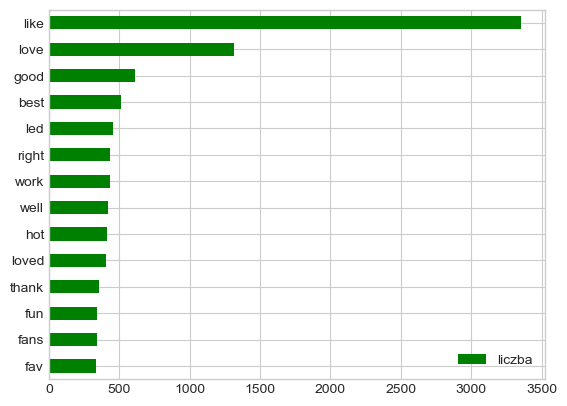

In [433]:
#Zwizualizuj wykrytych 14 pozytywnych słów
pozytywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)[1:15].plot(kind = 'barh', color = 'green')
plt.gca().invert_yaxis()

In [434]:
#Częstość występowania pozytywnych słów w korpusie
wystapienia = [] #utworzenie pustej listy

with open('negatywne_slowa.txt', encoding = "latin1") as file: #otworzenie pliku tekstoweo z pozytywnymi słowami
    
    negatywne_slowa = file.read().split('\n') #zapisanie pozytywnych słów do zmiennej

    for slowo in negatywne_slowa: #pętl po słowach pozytywnych
        wystapienia.append(tekst.count(slowo.strip())) #zliczenie słów pozytywnych w tekście za pomocą funkcji count
        
negatywne_slowa_wystapienia = pd.DataFrame(wystapienia, index=negatywne_slowa, columns=['liczba']) #zapisanie występujących pozytywnych słów do ramki danych

In [435]:
negatywne_conjamniej_raz = negatywne_slowa_wystapienia[negatywne_slowa_wystapienia.liczba >1]
negatywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)

,liczba
,1295480
ugh,1455
sin,1201
mad,665
din,645
...,...
madness,2
exaggeration,2
bugs,2
indulge,2


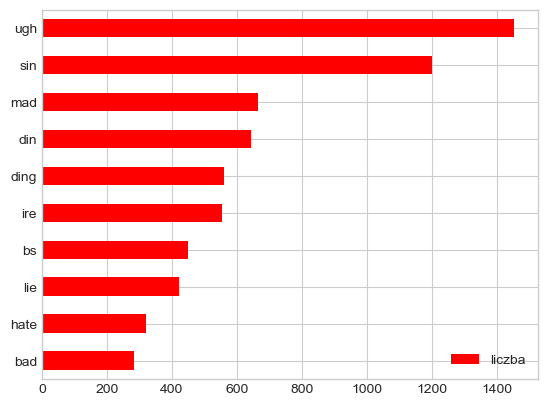

In [436]:
negatywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)[1:11].plot(kind = 'barh', color = 'red')
plt.gca().invert_yaxis()

In [437]:
#VADER

In [438]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#Wywołaj i przypisz do zmiennej model za pomocą funkcji SentimentIntensityAnalyzer()
sia = SentimentIntensityAnalyzer()
#Sprawdź przypisany sentyment do słow zwartych w słowniku Vadera za pomocą funkcji oboiekt.lexicon
sia.lexicon
data_hannah['tresc'] = data_hannah['tresc'].apply(normalize_text)
data_hannah['vader'] = data_hannah['tresc'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
data_hannah

/var/folders/nv/6k4klf9570d71xlr82yxfpw40000gn/T/ipykernel_34237/3155558445.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/nv/6k4klf9570d71xlr82yxfpw40000gn/T/ipykernel_34237/3155558445.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc,vader
7877,comments,hannahmontana,2024-01-01,2024,kfvdwr9,18fsuvk,ArcticHM,NaN,This is weirder than a three eyed billygoat in...,1,NaN,This is weirder than a three eyed billygoat in...,-0.1280
7878,comments,hannahmontana,2024-01-06,2024,kgl1zfb,18i3a3a,Dramatic_Scholar9385,NaN,"I think so in Hannah Montana: The Movie, Miley...",1,NaN,"I think so in Hannah Montana: The Movie, Miley...",0.0000
7879,comments,hannahmontana,2024-01-07,2024,kgp64y6,190iy7o,Ill-Glass4212,NaN,"I said it before, but I won't say 100% that Ja...",-2,NaN,"I said it before, but I won't say 100% that Ja...",-0.9127
7880,comments,hannahmontana,2024-01-07,2024,kgql84f,190iy7o,raighsunshine,NaN,season 1 & 2 is superior enough said,4,NaN,season 1 & 2 is superior enough said,0.5423
7881,comments,hannahmontana,2024-01-07,2024,kgr9st7,18admlw,Comfortable-Hall1178,NaN,"There was gonna be a new Lizzie McGuire show, ...",1,NaN,"There was gonna be a new Lizzie McGuire show, ...",0.5267
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24451,posts,hannahmontana,2026-05-13,2026,1tc40b8,NaN,New_Persimmon_3507,Does anyone know where I can find the tie-fron...,NaN,1,0.0,Does anyone know where I can find the tie-fron...,0.0000
24452,posts,hannahmontana,2026-05-13,2026,1tcc8t2,NaN,KaroFlower,Jackson Rod Stewart once said: ⤵️,NaN,1,0.0,Jackson Rod Stewart once said: ⤵️,0.0000
24453,posts,hannahmontana,2026-05-14,2026,1tcqdad,NaN,BANANA27_,Confused on Oliver and Joannie’s timeline,NaN,1,0.0,Confused on Oliver and Joannie’s timeline,-0.3182
24454,posts,hannahmontana,2026-05-14,2026,1tcrp1j,NaN,HappyCrow11,The test of my love episode is one of my favou...,NaN,1,0.0,The test of my love episode is one of my favou...,0.6369


<Axes: >

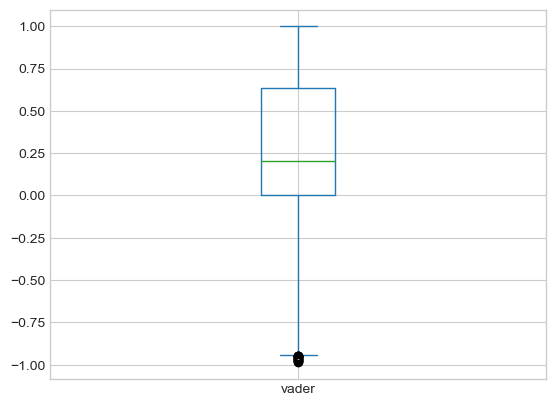

In [439]:
data_hannah['vader'].plot.box()

<Axes: ylabel='vader'>

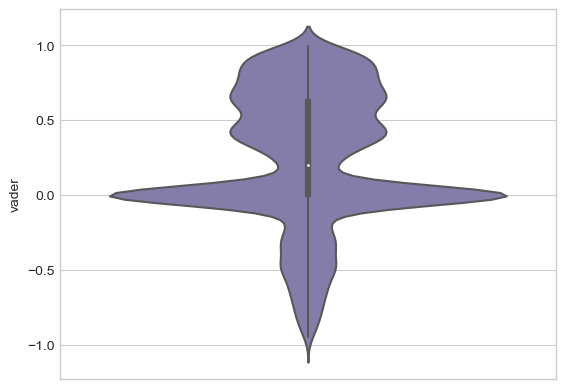

In [440]:
sns.violinplot(y=data_hannah['vader'], color = "#8074B2")

In [441]:
data_hannah["label"] = data_hannah["vader"].apply(
    lambda x: "pos" if x >= 0.05 else
              "neg" if x <= -0.05 else
              "neu"
)
data_hannah['tresc']

/var/folders/nv/6k4klf9570d71xlr82yxfpw40000gn/T/ipykernel_34237/1369920985.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



7877     This is weirder than a three eyed billygoat in...
7878     I think so in Hannah Montana: The Movie, Miley...
7879     I said it before, but I won't say 100% that Ja...
7880                  season 1 & 2 is superior enough said
7881     There was gonna be a new Lizzie McGuire show, ...
                               ...                        
24451    Does anyone know where I can find the tie-fron...
24452                    Jackson Rod Stewart once said: ⤵️
24453            Confused on Oliver and Joannie’s timeline
24454    The test of my love episode is one of my favou...
24455    Am I the only one who thinks Miley Stewart has...
Name: tresc, Length: 16103, dtype: object

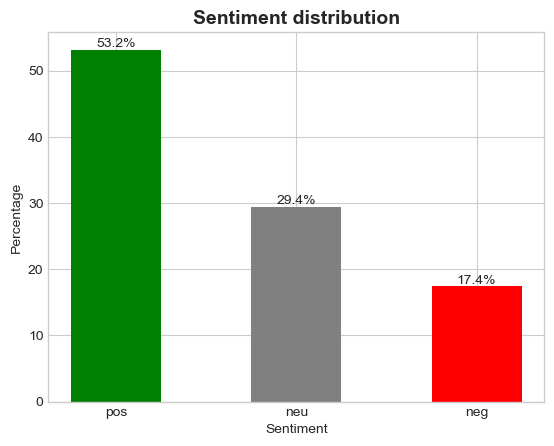

In [442]:
counts = data_hannah["label"].value_counts(normalize=True) * 100

bars = plt.bar(counts.index, counts.values, color=["green", "gray", "red"], width = 0.5)

plt.style.use("seaborn-v0_8-whitegrid")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )
plt.title("Sentiment distribution", fontsize=14, weight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")

plt.show()